# How to generate a membership inference attacks report?

### Check that the synthetic data protect the privacy of the real data

The synthetic data needs to be generated with the proposed synthetic data generatros
Based on the Adult Dataset

In [1]:
# Standard library
import sys

sys.path.append("..")
import tempfile
from pathlib import Path

# 3rd party packages
import pandas as pd

# Local packages
from generators.ctabgan_generator import CTABGANGenerator
from generators.ctgan_generator import CTGANGenerator
from generators.dataSynthesizer import DataSynthesizerGenerator
from generators.mst_generator import MSTGenerator
from generators.smote import SmoteGenerator
from generators.synthpop_generator import SynthpopGenerator
from generators.tabddpm_generator import TabDDPMGenerator
from generators.tvae_generator import TVAEGenerator
from metrics.privacy.report import PrivacyReport
from sklearn.model_selection import train_test_split

## Generate synthetic data

### Load the real Adult dataset

In [2]:
header_names = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "salary",
]

df_real = pd.read_csv("../data/" + "adult.data", names=header_names, index_col=False)
df_real.shape

(32561, 15)

In [3]:
df_real.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Split the real data into train and test sets

In [4]:
df_real_train, df_real_test = train_test_split(
    df_real, test_size=0.2, random_state=42, stratify=df_real["salary"]
)

In [5]:
df_real_train.to_csv("../data/adult_train.csv", index=False)
df_real_test.to_csv("../data/adult_test.csv", index=False)

### Create the metadata dictionary
The continuous and categorical variables need to be specified, as well as the variable to predict for the future learning task (used by SMOTE)

In [6]:
metadata = {
    "continuous": [
        "age",
        "fnlwgt",
        "education-num",
        "capital-gain",
        "capital-loss",
        "hours-per-week",
    ],
    "categorical": [
        "workclass",
        "education",
        "marital-status",
        "occupation",
        "relationship",
        "race",
        "sex",
        "native-country",
        "salary",
    ],
    "variable_to_predict": "salary",
}

### Choose a generator

In [7]:
generator = "synthpop"  # to choose among this list: ["synthpop", "smote", "datasynthesizer", "mst", "ctgan", "tvae", "ctabgan", "tabDDPM"]

In [8]:
if generator == "synthpop":
    gen = SynthpopGenerator(
        df=df_real_train,
        metadata=metadata,
        random_state=42,  # for reproducibility, can be set to None
        generator_filepath=None,  # to load an existing generator,
        variables_order=None,  # use the dataframe columns order by default
        min_samples_leaf=5,  # default = 5
        max_depth=None,
    )

### Fit the generator to the real train data

In [9]:
gen.preprocess()
gen.fit(save_path="../results/attack/generator/1st_generation")  # the path should exist

### Generate synthetic data

In [10]:
df_synth_train = gen.sample(
    save_path="../results/attack/data/1st_generation",  # the path should exist
    num_samples=len(df_real_train),
)

In [11]:
df_synth_test = gen.sample(
    save_path="../results/attack/data/1st_generation",  # the path should exist
    num_samples=len(df_real_test),
)

### Generate 2nd generation synthetic data

In [12]:
if generator == "synthpop":
    gen_2nd = SynthpopGenerator(
        df=df_synth_train,
        metadata=metadata,
        random_state=42,  # for reproducibility, can be set to None
        generator_filepath=None,  # to load an existing generator,
        variables_order=None,  # use the dataframe columns order by default
        min_samples_leaf=5,  # default = 5
        max_depth=None,
    )

In [13]:
gen_2nd.preprocess()
gen_2nd.fit(
    save_path="../results/attack/generator/2nd_generation"
)  # the path should exist

In [14]:
df_synth_2nd = gen_2nd.sample(
    save_path="../results/attack/data/2nd_generation",  # the path should exist
    num_samples=len(df_synth_train),
)

## Generate privacy report

### Gethor real and synthetic data into dictionaries

In [15]:
df_real_dict = {}
df_real_dict["train"] = df_real_train
df_real_dict["test"] = df_real_test

# 1st and 2nd generation synthetic data
df_synth_dict = {}
df_synth_dict["train"] = df_synth_train
df_synth_dict["test"] = df_synth_test
df_synth_dict["2nd_gen"] = df_synth_2nd

### Generate the privacy report

In [18]:
report = PrivacyReport(
    dataset_name="Adult Dataset",
    df_real=df_real_dict,
    df_synthetic=df_synth_dict,
    metadata=metadata,
    figsize=(8, 6),  # will be automatically adjusted for larger or longer figures
    random_state=None,  # for reproducibility purposes
    report_filepath=None,  # load a computed report if available
    metrics=None,  # list of the metrics to compute. If not specified, all the metrics are computed.
    sampling_frac=1.0,  # the fraction of data to sample from real and synthetic datasets for better computing performance
    num_repeat=5,  # for the metrics relying on predictions
    num_kfolds=3,  # the number of folds to tune the hyperparameters for the metrics relying on predictors
    num_optuna_trials=15,  # the number of trials of the optimization process for tuning hyperparameters for the metrics relying on predictors
    use_gpu=True,  # run the learning tasks on the GPU
)

In [19]:
report.compute()

### Get the summary report as a pandas dataframe

In [20]:
report.specification()

----- Adult Dataset -----
Contains:
    - 26048 instances in the train set,
    - 6513 instances in the test set,
    - 15 variables, 6 continuous and 9 categorical.


In [21]:
df_summary = report.summary()

In [22]:
by = ["name", "objective", "min", "max"]
df_summary.groupby(by).apply(lambda x: x.drop(by, axis=1).reset_index(drop=True))

alias  \
name                   objective min max                  
Collision              max       0   1.0 0    collision   
                                         1    collision   
                                         2    collision   
                                         3    collision   
                                     inf 0    collision   
                                         1    collision   
                                         2    collision   
                                         3    collision   
                                         4    collision   
DCR                    max       0   1.0 0          dcr   
                                         1          dcr   
                                     inf 0          dcr   
                                         1          dcr   
                       min       0   1.0 0          dcr   
                                         1          dcr   
Detector               max       0   1.0 0     detector   
                                         1     detector   
                                         2     detector   
                                         3     detector   
                                         4     detector   
GAN-Leaks              max       0   1.0 0     ganleaks   
                                         1     ganleaks   
LOGAN                  max       0   1.0 0        logan   
                                         1        logan   
                                         2        logan   
                                         3        logan   
                                         4        logan   
Monte Carlo Membership max       0   1.0 0  mcmebership   
                                         1  mcmebership   
TableGan               max       0   1.0 0     tablegan   
                                         1     tablegan   
                                         2     tablegan   
                                         3     tablegan   
                                         4     tablegan   

                                                                     submetric  \
name                   objective min max                                         
Collision              max       0   1.0 0                           precision   
                                         1                              recall   
                                         2                            f1_score   
                                         3                       recovery_rate   
                                     inf 0        avg_num_appearance_realtrain   
                                         1      avg_num_appearance_realcontrol   
                                         2            avg_num_appearance_synth   
                                         3   avg_num_appearance_collision_real   
                                         4  avg_num_appearance_collision_synth   
DCR                    max       0   1.0 0    nndr_5th_percent_synthreal_train   
                                         1  nndr_5th_percent_synthreal_control   
                                     inf 0     dcr_5th_percent_synthreal_train   
                                         1   dcr_5th_percent_synthreal_control   
                       min       0   1.0 0         ratio_match_synthreal_train   
                                         1       ratio_match_synthreal_control   
Detector               max       0   1.0 0                     precision_top1%   
                                         1                    precision_top50%   
                                         2                           precision   
                                         3                   tpr_at_0.001%_fpr   
                                         4                     tpr_at_0.1%_fpr   
GAN-Leaks              max       0   1.0 0                     precision_top1%   
                                       

### Display the detailed report

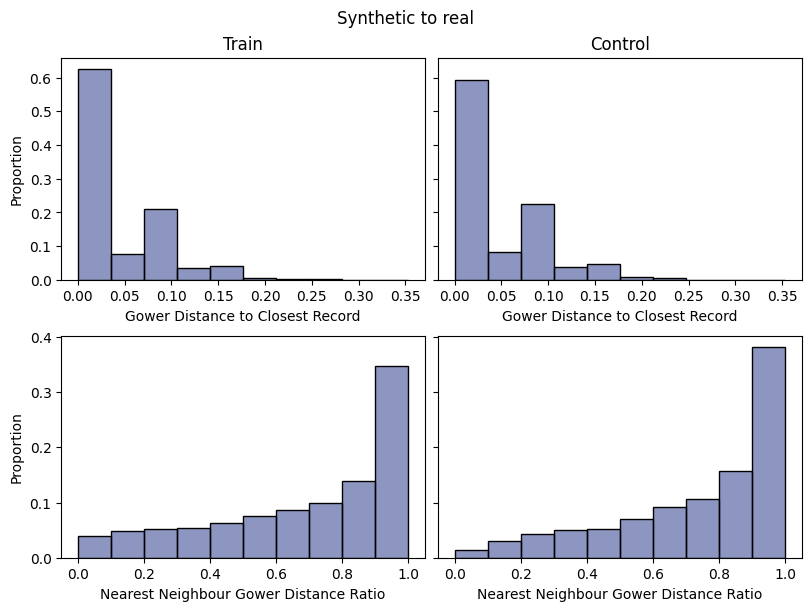

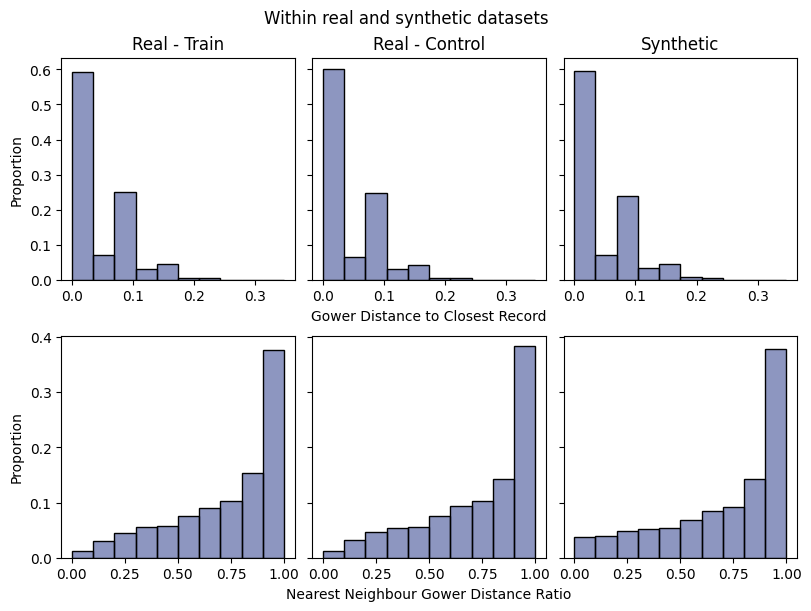

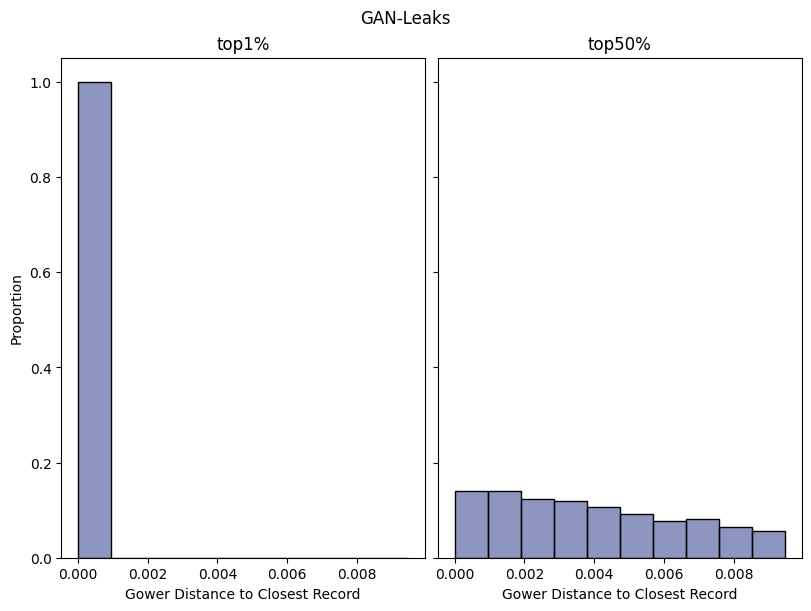

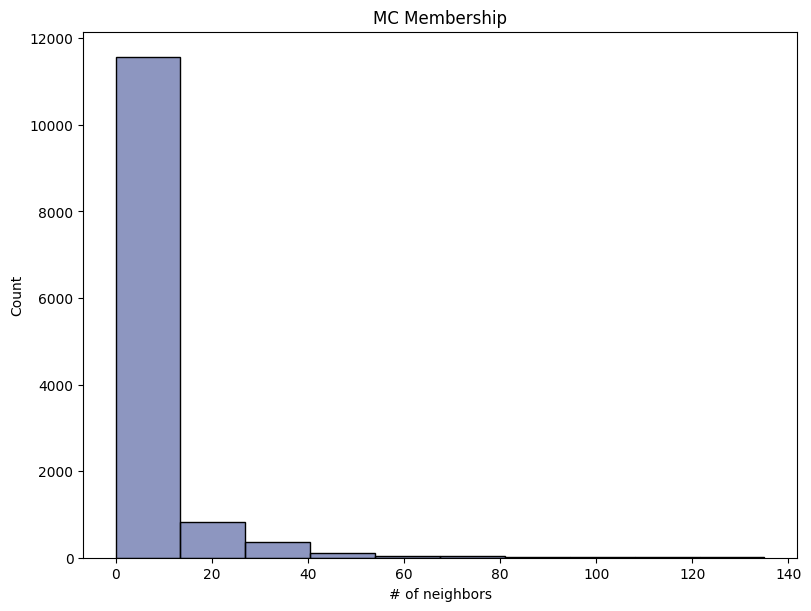

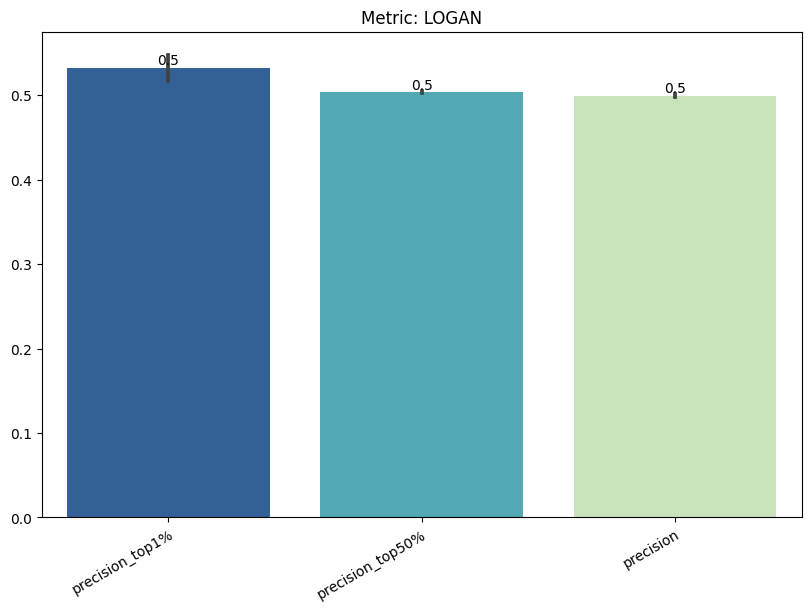

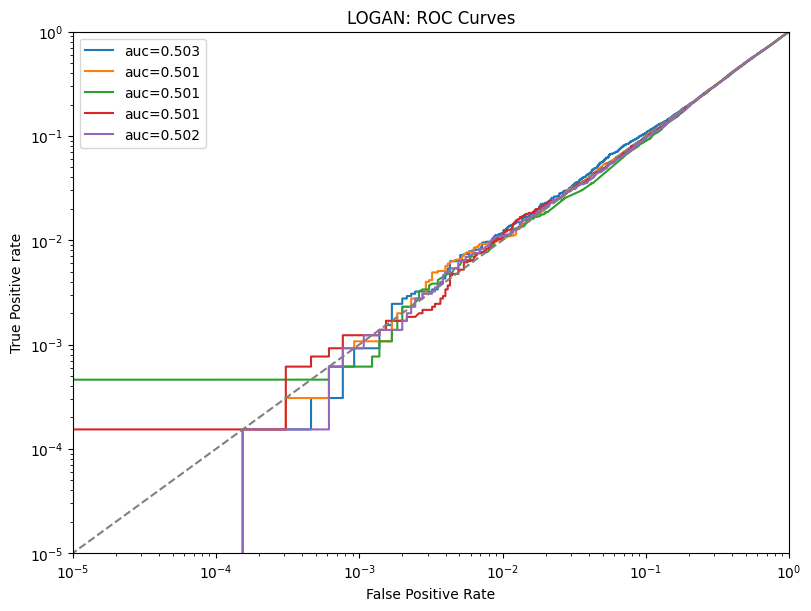

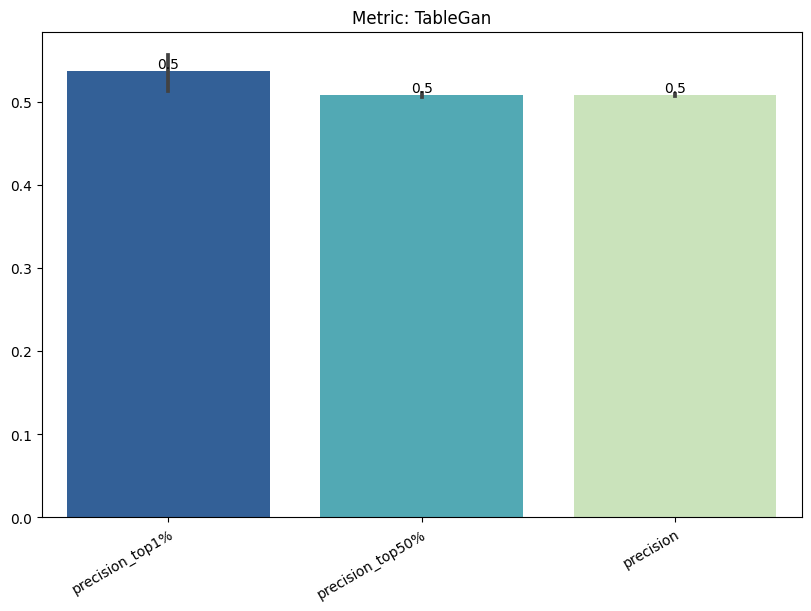

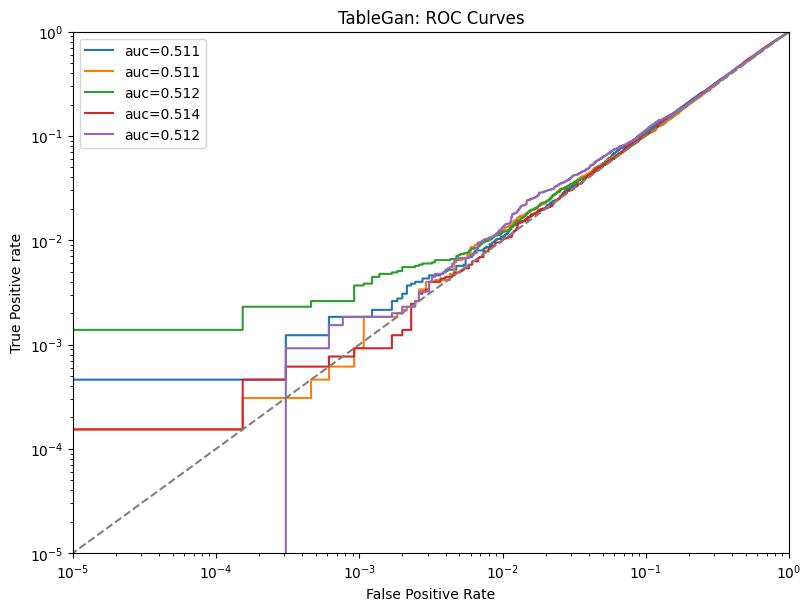

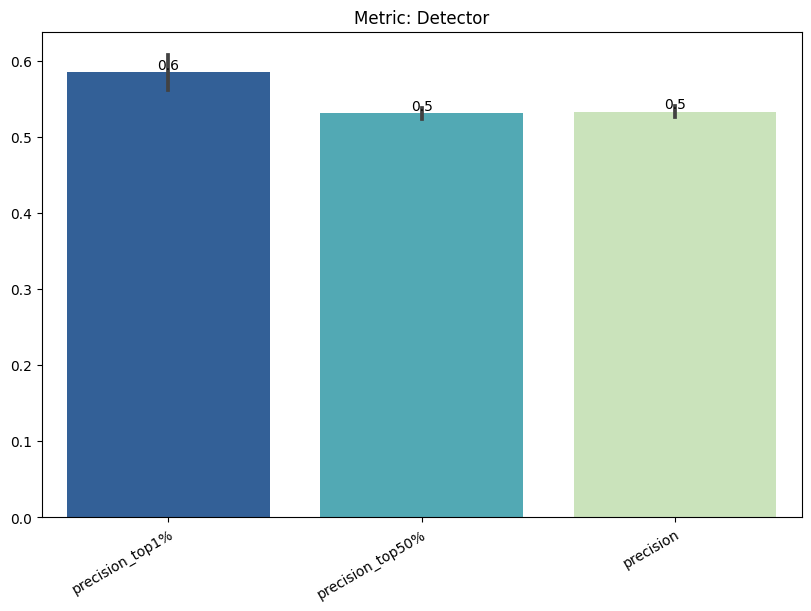

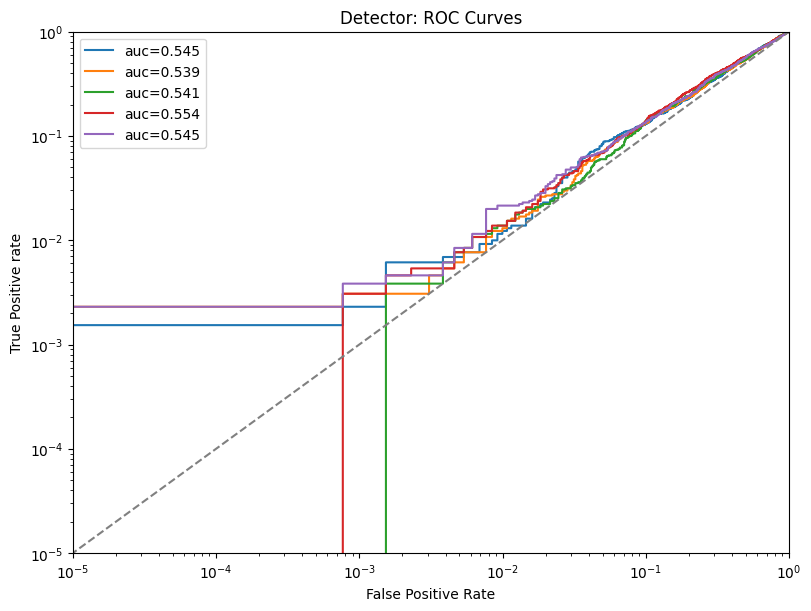

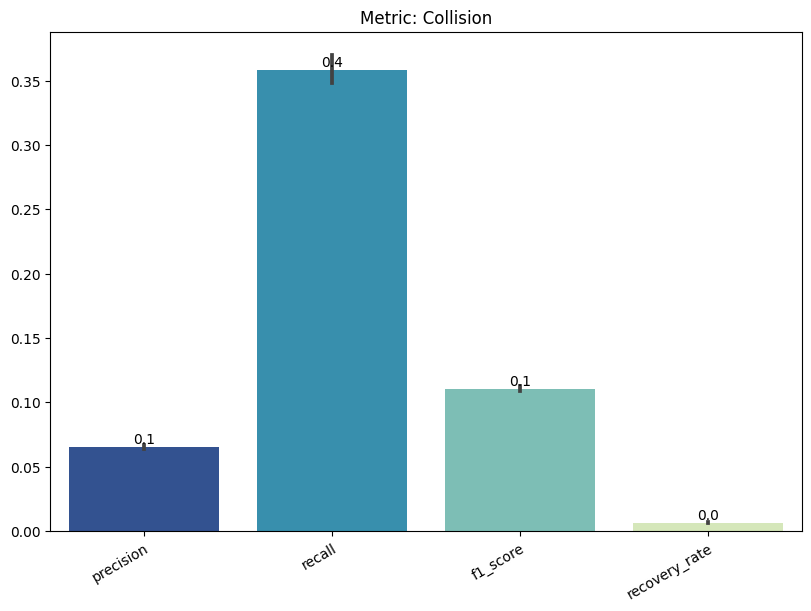

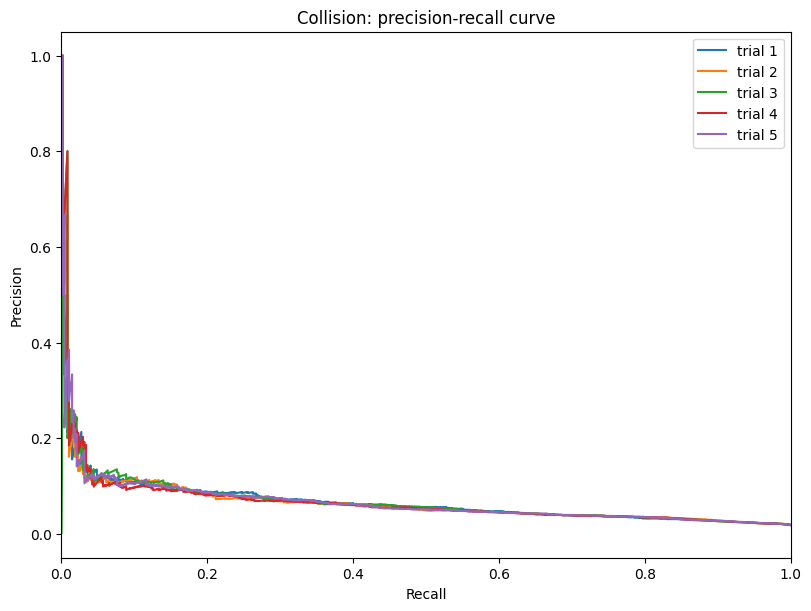

In [23]:
report.detailed(show=True, save_folder=None, figure_format="png")

### Save and load the report

In [27]:
with tempfile.TemporaryDirectory() as temp_dir:
    report.save(savepath=temp_dir, filename="privacy_report")  # save
    new_report = PrivacyReport(
        report_filepath=Path(temp_dir) / "privacy_report.pkl"
    )  # load